## 2026-27 Live Title Simulation

---
## Step 1 - Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
import soccerdata as sd

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.metrics import log_loss, accuracy_score

warnings.filterwarnings('ignore')
%matplotlib inline

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

TITLE_TEAMS = ['Arsenal', 'Liverpool', 'Manchester City', 'Manchester United']
BIG6 = ['Arsenal', 'Liverpool', 'Manchester City', 'Manchester United', 'Chelsea', 'Tottenham']

RIVALRIES = {
    'Arsenal': ['Tottenham', 'Manchester United', 'Chelsea', 'Manchester City'],
    'Brentford': ['Fulham', 'Chelsea'],
    'Everton': ['Liverpool'],
    'Hull': ['Leeds'],
    'Ipswich': [],  # Main rival (Norwich City) is not in the Premier League this season
    'Nottingham Forest': ['Coventry', 'Aston Villa'],
    'Brighton': ['Crystal Palace', 'Bournemouth'],
    'Manchester City': ['Manchester United', 'Liverpool', 'Arsenal'],
    'Newcastle United': ['Sunderland'],
    'Fulham': ['Chelsea', 'Brentford'],
    'Crystal Palace': ['Brighton'],
    'Bournemouth': ['Brighton'],
    'Coventry': ['Aston Villa', 'Nottingham Forest'],
    'Liverpool': ['Manchester United', 'Everton', 'Manchester City', 'Chelsea'],
    'Tottenham': ['Arsenal', 'Chelsea'],
    'Chelsea': ['Arsenal', 'Tottenham', 'Fulham', 'Leeds', 'Liverpool'],
    'Leeds': ['Manchester United', 'Chelsea', 'Hull'],
    'Manchester United': ['Liverpool', 'Manchester City', 'Leeds', 'Arsenal'],
    'Sunderland': ['Newcastle United'],
    'Aston Villa': ['Coventry', 'Nottingham Forest']
}

ARTETA_SEASONS = ['1920', '2021', '2122', '2223', '2324', '2425', '2526']

TEAM_PALETTE = {
    'Arsenal':            '#EF0107',
    'Liverpool':          '#00B2A9',
    'Manchester City':    '#6CABDD',
    'Manchester United':  '#FFB81C',
}

RNG_SEED = 42
rng = np.random.default_rng(RNG_SEED)

print('Imports ready')

[09/21/26 23:41:58] INFO     No custom team name replacements found. You can configure these in       ]8;id=8653123;file://C:\Users\tejas\anaconda3\envs\arsenal\Lib\site-packages\soccerdata\_config.py\_config.py]8;;\:]8;id=8653124;file://C:\Users\tejas\anaconda3\envs\arsenal\Lib\site-packages\soccerdata\_config.py#91\91]8;;\
                             C:\Users\tejas\soccerdata\config\teamname_replacements.json.                          

                    INFO     No custom league dict found. You can configure additional leagues in    ]8;id=8653130;file://C:\Users\tejas\anaconda3\envs\arsenal\Lib\site-packages\soccerdata\_config.py\_config.py]8;;\:]8;id=8653131;file://C:\Users\tejas\anaconda3\envs\arsenal\Lib\site-packages\soccerdata\_config.py#189\189]8;;\
                             C:\Users\tejas\soccerdata\config\league_dict.json.                                    

Imports ready

---
## Step 2 - Load Data

In [2]:
NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent
RAW_DATA_DIR = PROJECT_ROOT / 'data' / 'raw'
PROC_DATA_DIR = PROJECT_ROOT / 'data' / 'processed'

df = pd.read_csv(PROC_DATA_DIR / 'all_4teams_processed.csv')
df['date'] = pd.to_datetime(df['date'])
df['season'] = df['season'].astype(str)

print(f'Shape: {df.shape}')

Shape: (1064, 37)

---
## Section A - What a Monte Carlo Simulation Actually Is

A quick illustration of drawing random outcomes from a fixed probability triple, confirming the sampling mechanic behaves as expected before it gets used for real.

In [3]:
# a quick illustration: one match, simulated 10,000 times, using its own random draw each time
p_win, p_draw, p_loss = 0.60, 0.25, 0.15

outcomes = rng.choice(['Win', 'Draw', 'Loss'], size=10000, p=[p_win, p_draw, p_loss])
observed = pd.Series(outcomes).value_counts(normalize=True).reindex(['Win', 'Draw', 'Loss'])

print('Input probabilities:  Win 0.60, Draw 0.25, Loss 0.15')
print('Observed frequency across 10,000 independent draws:')
print(observed.round(3))

Input probabilities:  Win 0.60, Draw 0.25, Loss 0.15

Observed frequency across 10,000 independent draws:

Win     0.605
Draw    0.248
Loss    0.148
Name: proportion, dtype: float64

### Reading Section A

The observed frequencies (0.605 win, 0.248 draw, 0.148 loss) land close to the input probabilities of 0.60, 0.25 and 0.15 but not exactly on them. That gap is sampling noise, the same reason 10,000 coin flips rarely give exactly 5,000 heads, and it is the point of the method. Every simulated match is a random draw from fixed odds, so a season built from hundreds of them comes out differently each time it is run, and the spread across many runs is what turns match probabilities into a distribution of final tables.

---
## Section B - The Live Data Problem

NB01's `fixtures_26-27.csv` / `all_teams_26-27_raw.csv` were scraped from FBRef with `xG`/`xGA` left blank and may be several gameweeks stale. Check their actual state directly rather than assuming a file called "raw" is current.

In [4]:
fx_old = pd.read_csv(RAW_DATA_DIR / 'all_teams_26-27_raw.csv')
print(f'Rows: {len(fx_old)}, played (non-null scored): {fx_old["scored"].notna().sum()}')
print(f'xG non-null count: {fx_old["xG"].notna().sum()}')
print(f'Max gameweek with a real result: {fx_old.loc[fx_old["scored"].notna(), "gameweek"].max()}')

Rows: 760, played (non-null scored): 20

xG non-null count: 0

Max gameweek with a real result: 1

Two problems with the old file, checked directly. The xG and xGA columns are empty for every row, and only gameweek 1 has any results even though several gameweeks have been played since. Understat is where the live results actually are, so the next cell checks it.

In [5]:
u_check = sd.Understat(leagues='ENG-Premier League', seasons='2627', no_cache=True)
sched_check = u_check.read_schedule().reset_index()
sched_check['date'] = pd.to_datetime(sched_check['date'])
played = sched_check[sched_check['home_goals'].notna()]

print(f'Understat 2026-27 matches with a real result: {len(played)}')
print(f'Latest played date: {played["date"].max()}')
print()
print('A sample played match, home_xg/away_xg populated:')
print(played[['date','home_team','away_team','home_goals','away_goals','home_xg','away_xg']].tail(3).to_string(index=False))

[09/21/26 23:41:59] INFO     Saving cached data to C:\Users\tejas\soccerdata\data\Understat          ]8;id=8653138;file://C:\Users\tejas\anaconda3\envs\arsenal\Lib\site-packages\soccerdata\_common.py\_common.py]8;;\:]8;id=8653139;file://C:\Users\tejas\anaconda3\envs\arsenal\Lib\site-packages\soccerdata\_common.py#250\250]8;;\

[2026-09-21 23:41:59] INFO     TLSLibrary:_load_library:397 - Successfully loaded TLS library: C:\Users\tejas\anaconda3\envs\arsenal\Lib\site-packages\tls_requests\bin\tls-client-xgo-1.13.1-windows-amd64.dll


                    INFO     Successfully loaded TLS library:                                      ]8;id=8653146;file://C:\Users\tejas\anaconda3\envs\arsenal\Lib\site-packages\tls_requests\models\libraries.py\libraries.py]8;;\:]8;id=8653147;file://C:\Users\tejas\anaconda3\envs\arsenal\Lib\site-packages\tls_requests\models\libraries.py#397\397]8;;\
                             C:\Users\tejas\anaconda3\envs\arsenal\Lib\site-packages\tls_requests\                 
                             bin\tls-client-xgo-1.13.1-windows-amd64.dll                                           

Understat 2026-27 matches with a real result: 50

Latest played date: 2026-09-20 15:30:00

A sample played match, home_xg/away_xg populated:

               date       home_team         away_team  home_goals  away_goals  home_xg  away_xg
2026-09-20 15:30:00          Fulham Manchester United           1           1  1.71719  2.12453
2026-09-20 13:00:00           Leeds    Crystal Palace           0           0  1.08552  1.12905
2026-09-20 13:00:00 Manchester City        Sunderland           5           3  2.66856  3.10661

### Reading Section B

Understat has 50 real results with xG, the latest on 2026-09-20, against 20 played rows in the old file. The old scrape was not wrong when it ran, results simply kept happening afterwards. A live simulator only makes sense if today's table is today's, so the live data comes from Understat, pulled with no_cache=True because soccerdata otherwise serves whatever it stored the first time it saw the season. Understat's team names also already match the ones used in NB02 to NB06, apart from Hull and Coventry, which are newly promoted and have no history in this project. FBRef used different names from Understat for seven of the twenty clubs.

---
## Section C - Building the Live Update

Pull the current 20-team schedule fresh from Understat (`no_cache=True`), reshape it into this project's usual team-per-row long format, and write it to new `fixtures_26-27_live.csv` / `all_teams_26-27_live.csv` files, leaving NB01's original output untouched.

In [6]:
def fetch_live_schedule(season='2627'):
    u = sd.Understat(leagues='ENG-Premier League', seasons = season, no_cache=True)
    sched = u.read_schedule().reset_index()
    sched['date'] = pd.to_datetime(sched['date'])

    home = sched.rename(columns={
        'home_team': 'team', 'away_team': 'opponent',
        'home_goals': 'scored', 'away_goals': 'conceded',
        'home_xg': 'xG', 'away_xg': 'xGA',        
    })
    home['venue'] = 'home'
    away = sched.rename(columns={
        'away_team': 'team', 'home_team': 'opponent',
        'away_goals': 'scored', 'home_goals': 'conceded',
        'away_xg': 'xG', 'home_xg': 'xGA',
    })
    away['venue'] = 'away'

    cols = ['league', 'season', 'game_id', 'date', 'team', 'opponent', 'venue', 'xG', 'xGA', 'scored', 'conceded']
    long = pd.concat([home[cols], away[cols]], ignore_index=True)
    long['gameweek'] = long.groupby('team')['date'].rank(method='dense').astype(int)
    return long.sort_values(['team','date']).reset_index(drop=True)

live_2627 = fetch_live_schedule()
print(f'Live 2026-27 long format: {live_2627.shape}')
print(f'Teams: {live_2627["team"].nunique()}')
print(f'Played rows: {live_2627["scored"].notna().sum()} / {len(live_2627)}')
print(f'Latest played gameweek: {live_2627.loc[live_2627["scored"].notna(), "gameweek"].max()}')

[09/21/26 23:42:04] INFO     Saving cached data to C:\Users\tejas\soccerdata\data\Understat          ]8;id=8653152;file://C:\Users\tejas\anaconda3\envs\arsenal\Lib\site-packages\soccerdata\_common.py\_common.py]8;;\:]8;id=8653153;file://C:\Users\tejas\anaconda3\envs\arsenal\Lib\site-packages\soccerdata\_common.py#250\250]8;;\

Live 2026-27 long format: (760, 12)

Teams: 20

Played rows: 100 / 760

Latest played gameweek: 5

In [7]:
all20_live = live_2627.copy()
tracked_live = live_2627[live_2627['team'].isin(TITLE_TEAMS)].copy()

all20_live.to_csv(RAW_DATA_DIR / 'all_teams_26-27_live.csv', index=False)
tracked_live.to_csv(RAW_DATA_DIR / 'fixtures_26-27_live.csv', index=False)

print(f'Wrote all_teams_26-27_live.csv : {len(all20_live)} rows')
print(f'Wrote fixtures_26-27_live.csv  : {len(tracked_live)} rows')

Wrote all_teams_26-27_live.csv : 760 rows

Wrote fixtures_26-27_live.csv  : 152 rows

### Reading Section C

The live file now holds 100 played team-rows, which is five gameweeks for all 20 clubs, each with xG. That cell is the whole update. Nothing runs it on a schedule, it is a cell to rerun after a gameweek finishes, and it overwrites the two _live files with whatever Understat holds at that point. NB01's original fixture files are untouched.

---
## Section D - Scope: One Model, Not Two

A genuine title race needs all 20 teams, not just the 4 tracked here. Training a second, simpler model for the other 16 looks reasonable, check whether it introduces a population bias before committing to it.

In [8]:
# rebuild the two-model version first, to see the problem directly
hist = sd.Understat(leagues='ENG-Premier League', seasons=ARTETA_SEASONS)
hist_sched = hist.read_schedule().reset_index()
hist_sched['date'] = pd.to_datetime(hist_sched['date'])

def wide_to_long(sched):
    home = sched.rename(columns={'home_team':'team','away_team':'opponent','home_goals':'scored',
                                   'away_goals':'conceded','home_xg':'xG','away_xg':'xGA'})
    home['venue'] = 'home'
    away = sched.rename(columns={'away_team':'team','home_team':'opponent','away_goals':'scored',
                                   'home_goals':'conceded','away_xg':'xG','home_xg':'xGA'})
    away['venue'] = 'away'
    cols = ['league','season','game_id','date','team','opponent','venue','xG','xGA','scored','conceded']
    return pd.concat([home[cols], away[cols]], ignore_index=True).sort_values(['team','season','date']).reset_index(drop=True)

full_long = wide_to_long(hist_sched)
for c in ['scored','conceded','xG','xGA']:
    full_long[c] = full_long[c].astype('float64')

full_long['result'] = np.where(full_long['scored'] > full_long['conceded'], 'W',
    np.where(full_long['scored'] == full_long['conceded'], 'D','L'))
full_long['points'] = full_long['result'].map({'W':3,'D':1,'L':0})
full_long['xgd'] = full_long['xG']- full_long['xGA']
full_long['is_win'] = (full_long['result'] == 'W').astype(float)
full_long['is_home'] = (full_long['venue'] == 'home').astype(int)
full_long['is_big6_opp'] = full_long['opponent'].isin(BIG6).astype(int)

def roll(g, col, window, min_p= 3):
    return g[col].transform(lambda x: x.shift(1).rolling(window, min_periods=min_p).mean())
g = full_long.groupby(['team','season'])
full_long['xG_roll5'] = roll(g, 'xG',5)
full_long['xGA_roll5'] = roll(g, 'xGA', 5)
full_long['pts_roll5'] = roll(g, 'points', 5)
full_long['win_rate_roll5'] = roll(g, 'is_win', 5)
full_long['xgd_roll5'] = roll(g, 'xgd', 5)

opp_lookup = full_long[['team','season','game_id','xgd_roll5']].rename(columns={'team':'opponent','xgd_roll5':'opp_xgd_roll5'})
full_long = full_long.merge(opp_lookup, on = ['opponent','season','game_id'], how = 'left')
full_long['parity_gap'] = (full_long['xgd_roll5'] - full_long['opp_xgd_roll5']).abs()

print(f'Full 20-team long shape: {full_long.shape}')

[09/21/26 23:42:10] INFO     Saving cached data to C:\Users\tejas\soccerdata\data\Understat          ]8;id=8653158;file://C:\Users\tejas\anaconda3\envs\arsenal\Lib\site-packages\soccerdata\_common.py\_common.py]8;;\:]8;id=8653159;file://C:\Users\tejas\anaconda3\envs\arsenal\Lib\site-packages\soccerdata\_common.py#250\250]8;;\

Full 20-team long shape: (5320, 24)

First the model for all 20 teams, using only features every club has, and what it predicts for a perfectly average match in its own training data.

In [9]:
FEATURES_T2 = ['xG_roll5','xGA_roll5','pts_roll5','win_rate_roll5','is_home','is_big6_opp','opp_xgd_roll5','parity_gap']

all_rows = full_long[full_long['season'].isin(ARTETA_SEASONS)].copy()
y_map = {'L':0,'D':1,'W':2}
all_rows['y'] = all_rows['result'].map(y_map)
t2_df = all_rows.dropna(subset = FEATURES_T2 + ['y']).copy()
t2_df['season_int'] = t2_df['season'].astype(int)
t2_train, t2_test = t2_df[t2_df['season_int']<=2425] , t2_df[t2_df['season_int'] == 2526]

sc2 = StandardScaler()
m2 = LogisticRegression(max_iter=2000).fit(sc2.fit_transform(t2_train[FEATURES_T2]), t2_train['y'])

avg_t2 = t2_train[FEATURES_T2].mean().to_frame().T
p_avg_t2 = m2.predict_proba(sc2.transform(avg_t2))[0]
print(f'Tier-2 model (all 20 teams), average team baseline -> L/D/W = {p_avg_t2.round(3)}')

Tier-2 model (all 20 teams), average team baseline -> L/D/W = [0.375 0.25  0.375]

Now the same check for the NB06 recipe, trained on the four tracked teams only, with the two baselines side by side.

In [10]:
FEATURES_T1 = ['xG_roll5','xGA_roll5','pts_roll5','win_rate_roll5','stakes_intensity','is_home',
               'is_big6_opp','is_non_big6_rivalry','opp_xgd_roll5']

t1_processed = pd.read_csv(PROC_DATA_DIR / 'all_4teams_processed.csv')
t1_processed['is_home'] = (t1_processed['venue'] == 'home')
t1_processed['y'] = t1_processed['result'].map(y_map)

# is_big6_opp / is_non_big6_rivalry / opp_xgd_roll5 aren't saved in the processed CSV,
# NB06 computed them inline, so this rebuilds the same 3 columns the same way
t1_processed['is_big6_opp'] = t1_processed['opponent'].isin(BIG6).astype(int)
t1_processed['is_non_big6_rivalry'] = (t1_processed['is_rivalry'] & (t1_processed['is_big6_opp']==0)).astype(int)
opp_lookup_t1 = full_long[['team','season','game_id','xgd_roll5']].rename(columns={'team':'opponent','xgd_roll5':'opp_xgd_roll5'})
t1_processed['season'] = t1_processed['season'].astype(str)
opp_lookup_t1['season'] = opp_lookup_t1['season'].astype(str)
t1_processed = t1_processed.merge(opp_lookup_t1, on=['opponent','season','game_id'], how='left')

t1_df = t1_processed.dropna(subset=FEATURES_T1 + ['y']).copy()
t1_df['season_int'] = t1_df['season'].astype(int)
t1_train = t1_df[t1_df['season_int']<=2425]

sc1 = StandardScaler()
m1 = LogisticRegression(max_iter=2000).fit(sc1.fit_transform(t1_train[FEATURES_T1]), t1_train['y'])
avg_t1 = t1_train[FEATURES_T1].mean().to_frame().T
p_avg_t1 = m1.predict_proba(sc1.transform(avg_t1))[0]
print(f'Tier-1 model (4 tracked teams), average team baseline -> L/D/W = {p_avg_t1.round(3)}')
print(f'Tier-2 model (all 20 teams),   average team baseline -> L/D/W = {p_avg_t2.round(3)}')
print(f'Win probability gap from model choice alone: {p_avg_t1[2]-p_avg_t2[2]:+.3f}')

Tier-1 model (4 tracked teams), average team baseline -> L/D/W = [0.181 0.213 0.606]

Tier-2 model (all 20 teams),   average team baseline -> L/D/W = [0.375 0.25  0.375]

Win probability gap from model choice alone: +0.232

### Reading Section D

For a perfectly average match the four-team model gives a 60.6% win probability and the all-20 model gives 37.5%, a gap of 23.2 points before either model has looked at anything about a specific match. That is not a form difference. The four-team model was trained on Arsenal, Liverpool, Manchester City and Manchester United, who won about 59% of their matches in this data, so it learned that as its starting point. Across all 20 teams every win is somebody else's loss, so the average sits close to 38%. Two separate models would give a tracked club that head start in every fixture regardless of how it is playing. The fix is a single model fitted on all 20 teams, so every club shares one starting point. stakes_intensity and is_non_big6_rivalry stay in it, and Section E extends them to all 20 clubs.

---
## Section E - Stakes Intensity for All 20 Teams

`title_gap`, `cl_gap`, and `eur_gap` already generalise to all 20 teams from NB02's full-schedule reconstruction. Extend `stakes_intensity` beyond the 4 tracked teams, and add the relegation boundary the original formula never needed.

In [11]:
# reconstruct the full stakes_intensity ingredients for ALL 20 teams
full_long['gameweek'] = full_long.groupby(['team','season'])['date'].rank(method='dense').astype(int)
full_long['cum_pts'] = full_long.groupby(['team','season'])['points'].transform(lambda x: x.fillna(0).cumsum())
full_long['leader_pts'] = full_long.groupby(['season','gameweek'])['cum_pts'].transform('max')
full_long['title_gap'] = full_long['leader_pts'] - full_long['cum_pts']

def nth_place_pts(x, n):
    return x.nlargest(n).iloc[-1] if len(x) >= n else x.min()

for n, name in [(4,'4th'), (5,'5th'), (6,'6th'), (7,'7th'), (17,'17th'), (18,'18th')]:
    full_long[f'pts_{name}'] = full_long.groupby(['season','gameweek'])['cum_pts'].transform(lambda x: nth_place_pts(x, n))

def boundary_gap(cum_pts, top, next_):
    return np.where(cum_pts >= top, top - next_, top - cum_pts)

full_long['cl_gap'] = boundary_gap(full_long['cum_pts'], full_long['pts_4th'], full_long['pts_5th'])
full_long['eur_gap'] = boundary_gap(full_long['cum_pts'], full_long['pts_6th'], full_long['pts_7th'])
# NOT boundary_gap here: that hands every safe team the same flat 17th-vs-18th cushion
# regardless of how far clear they are. Invisible for cl_gap/eur_gap since only 4-6 teams
# can ever be "safe" there and title_gap usually dominates anyway, but with up to 17 teams
# "safe" from relegation, it wrongly flagged mid-table teams with nothing else going on.
# Fixed by using each team's own distance above 18th place instead of the shared cushion.
full_long['releg_gap'] = np.where(
    full_long['cum_pts'] >= full_long['pts_17th'],
    full_long['cum_pts'] - full_long['pts_18th'],
    full_long['pts_17th'] - full_long['cum_pts']
)

GW38_MAX = 1 / (1 + np.exp(-0.2 * (38 - 22)))
gw_factor = 1 / (1 + np.exp(-0.2 * (full_long['gameweek'] - 22)))
pts_remaining = (38 - full_long['gameweek'] + 1) * 3

title_f = (1 - full_long['title_gap'] / pts_remaining).clip(lower=0)
cl_f = (1 - full_long['cl_gap'] / pts_remaining).clip(lower=0)
eur_f = (1 - full_long['eur_gap'] / pts_remaining).clip(lower=0)
releg_f = (1 - full_long['releg_gap'] / pts_remaining).clip(lower=0)

title_raw = gw_factor * title_f
cl_raw = gw_factor * cl_f * 0.75
eur_raw = gw_factor * eur_f * 0.50
releg_raw = gw_factor * releg_f * 0.80

base_stakes = np.maximum.reduce([title_raw, cl_raw, eur_raw, releg_raw]) / GW38_MAX

recent_form = full_long.groupby(['team','season'])['points'].transform(lambda x: x.shift(1).rolling(3, min_periods=1).mean()).fillna(1.5)
form_mult = np.where(recent_form < 1.0, 1.15, 1.0)
full_long['is_rivalry'] = full_long.apply(lambda r: r['opponent'] in RIVALRIES.get(r['team'], []), axis=1)
rivalry_bonus = np.where(full_long['is_rivalry'], 0.15, 0)

full_long['stakes_intensity'] = (base_stakes * form_mult + rivalry_bonus).clip(0, 1).round(4)
full_long['is_non_big6_rivalry'] = (full_long['is_rivalry'] & (full_long['is_big6_opp']==0)).astype(int)

print('stakes_intensity now computed for all 20 teams, not just the 4 tracked ones.')
print(full_long.groupby(full_long['team'].isin(TITLE_TEAMS))['stakes_intensity'].describe()[['mean','max']].round(3))

stakes_intensity now computed for all 20 teams, not just the 4 tracked ones.

        mean  max
team             
False  0.257  1.0
True   0.371  1.0

Checking the formula on 2025-26 gameweek 35, with 12 points left to play for, rather than trusting it because it runs. The rows shown are the top of the table, because clubs nowhere near the drop zone are where a badly behaved relegation term would show up.

In [12]:
snap_35 = full_long[(full_long['season']=='2526') & (full_long['gameweek']==35)].sort_values('cum_pts', ascending=False)
print('Whole table, 2025-26 GW35:')
print(snap_35[['team','cum_pts','title_gap','releg_gap','stakes_intensity']].head(8).round(3).to_string(index=False))

Whole table, 2025-26 GW35:

             team  cum_pts  title_gap  releg_gap  stakes_intensity
          Arsenal       76          0         40             0.969
  Manchester City       74          2         38             0.807
Manchester United       64         12         28             0.877
      Aston Villa       58         18         22             0.727
        Liverpool       58         18         22             0.877
      Bournemouth       52         24         16             0.444
        Brentford       51         25         15             0.511
         Brighton       50         26         14             0.404

The first version of the relegation boundary reused boundary_gap unchanged. On this same table it gave releg_gap = 1 to every team from Arsenal on 76 points down to West Ham on 36. boundary_gap hands every safe team one shared number, the gap between 17th and 18th place, so it cannot tell a club one point clear of the drop from one forty points clear. That never mattered for cl_gap and eur_gap, because only four to six clubs can be safe there and a real title contender's title_gap already decides the maximum. With up to 17 clubs safe from relegation, a mid-table club with nothing else to play for was picking up relegation stakes by default. The corrected version, in the first cell of this section, measures each safe club against its own distance above 18th place. The cell below reapplies it and prints the result.

In [13]:
# fix: for a safe team, use ITS OWN distance above the drop zone, not the shared cushion
full_long['releg_gap'] = np.where(
    full_long['cum_pts'] >= full_long['pts_17th'],
    full_long['cum_pts'] - full_long['pts_18th'],
    full_long['pts_17th'] - full_long['cum_pts']
)

releg_f = (1 - full_long['releg_gap'] / pts_remaining).clip(lower=0)
releg_raw = gw_factor * releg_f * 0.80
base_stakes = np.maximum.reduce([title_raw, cl_raw, eur_raw, releg_raw]) / GW38_MAX
full_long['stakes_intensity'] = (base_stakes * form_mult + rivalry_bonus).clip(0, 1).round(4)

snap_35 = full_long[(full_long['season']=='2526') & (full_long['gameweek']==35)].sort_values('cum_pts', ascending=False)
print('Same gameweek, fixed releg_gap:')
print(snap_35[['team','cum_pts','releg_gap','stakes_intensity']].head(8).round(3).to_string(index=False))

Same gameweek, fixed releg_gap:

             team  cum_pts  releg_gap  stakes_intensity
          Arsenal       76         40             0.969
  Manchester City       74         38             0.807
Manchester United       64         28             0.877
      Aston Villa       58         22             0.727
        Liverpool       58         22             0.877
      Bournemouth       52         16             0.444
        Brentford       51         15             0.511
         Brighton       50         14             0.404

### Reading Section E

With the corrected gap Arsenal's releg_gap is 40 and Manchester City's is 38, and their stakes_intensity does not change at all (0.969 and 0.807), because title_gap was already deciding it for a club chasing a title. The clubs that moved are the ones with no other storyline. Bournemouth on 52 points is at 0.444, Brentford on 51 at 0.511 and Brighton on 50 at 0.404, where the shared cushion had given each of them between 0.71 and 0.82. The relegation term now behaves like the other three boundaries, high when a club is close to the line and low when it is well clear of it.

stakes_intensity is now computed for all 20 clubs, averaging 0.257 for the sixteen untracked clubs and 0.371 for the four tracked ones, instead of being zero for sixteen of them. cl_gap and eur_gap are left as NB02 built them. The same flaw exists there in principle, but it has never changed a result.


---
## Section F - One More Real Signal: Head-to-Head Record

Test head-to-head record against the specific opponent, and whatever else seems worth trying, against the same holdout, keeping only what actually survives.

In [14]:
all_rows = full_long[full_long['season'].isin(ARTETA_SEASONS)].copy()
all_rows['y'] = all_rows['result'].map(y_map)

RECENCY = {'1920':1.0,'2021':1.0,'2122':1.0,'2223':1.1,'2324':1.2,'2425':1.3,'2526':1.5}
all_rows['recency_weight'] = all_rows['season'].map(RECENCY)

h2h = all_rows[['team','opponent','date','points']].sort_values(['team','opponent','date']).copy()
h2h['h2h_pts_avg3'] = h2h.groupby(['team','opponent'])['points'].transform(lambda x: x.shift(1).rolling(3, min_periods = 1).mean())
all_rows = all_rows.merge(h2h[['team','opponent','date','h2h_pts_avg3']], on = ['team','opponent','date'], how = 'left')
all_rows['h2h_pts_avg3'] = all_rows['h2h_pts_avg3'].fillna(1.5)

FEATURES = ['xG_roll5','xGA_roll5','pts_roll5','win_rate_roll5','is_home','is_big6_opp',
            'opp_xgd_roll5','parity_gap','stakes_intensity','is_non_big6_rivalry']
FEATURES_H2H = FEATURES + ['h2h_pts_avg3']


model_df = all_rows.dropna(subset=FEATURES_H2H + ['y']).copy()
model_df['season_int'] = model_df['season'].astype(int)
train, test = model_df[model_df['season_int']<=2425], model_df[model_df['season_int']==2526]

def fit_eval(features):
    sc = StandardScaler()
    Xtr, Xte = sc.fit_transform(train[features]), sc.transform(test[features])
    m = LogisticRegression(max_iter=2000).fit(Xtr, train['y'], sample_weight = train['recency_weight'])
    p = m.predict_proba(Xte)
    return log_loss(test['y'], p, labels=[0,1,2]), accuracy_score(test['y'], m.predict(Xte)), m, sc

ll_without, acc_without, _, _ = fit_eval(FEATURES)
ll_with, acc_with, m_final, sc_final = fit_eval(FEATURES_H2H)

print(f'Without head-to-head: log loss {ll_without:.4f}, accuracy {acc_without:.4f}')
print(f'With head-to-head:    log loss {ll_with:.4f}, accuracy {acc_with:.4f}')

dummy = DummyClassifier(strategy='prior').fit(train[FEATURES_H2H], train['y'])
p_dummy = dummy.predict_proba(test[FEATURES_H2H])
ll_dummy = log_loss(test['y'], p_dummy, labels=[0,1,2])
acc_dummy = accuracy_score(test['y'], dummy.predict(test[FEATURES_H2H]))
print(f'Dummy baseline:       log loss {ll_dummy:.4f}, accuracy {acc_dummy:.4f}')

Without head-to-head: log loss 1.0455, accuracy 0.4757

With head-to-head:    log loss 1.0362, accuracy 0.4886

Dummy baseline:       log loss 1.0984, accuracy 0.3600

### Reading Section F

Adding head-to-head record moves validation log loss from 1.0455 to 1.0362 and accuracy from 0.4757 to 0.4886 on the 2025-26 holdout. That is small, but it is the one candidate that held up. Splitting opponent strength into separate attack and defence terms, an is_promoted flag, and a stakes-times-Big-6 interaction were each tested the same way in a separate run and none of them improved log loss, so they are not in the pipeline.

The dummy baseline is the number to compare against. With a roughly 38/24/38 win, draw and loss split across all 20 teams, a model that only knows those base rates scores 1.0984 and 0.3600, so the model clears a much lower floor than the tracked-team model did in NB06, where always guessing a win was already right 59% of the time. Accuracy around 49% looks weak next to NB06's 56%, but the two are not on the same scale. Log loss is the metric that matters here, since the simulator draws directly from these probabilities.

---
## Section G - The Production Model, and What "Today" Means

Refit the chosen recipe on everything through 2025-26 rather than holding it back as a permanent test set, then build each team's frozen form snapshot as of their next unplayed 2026-27 fixture.

In [15]:
# rebuild the whole feature pipeline once more, this time on historical + live combined,
# so the rolling features and stakes_intensity extend all the way through today's real matches
live_sched = sd.Understat(leagues='ENG-Premier League', seasons='2627', no_cache=True).read_schedule().reset_index()
live_sched['date'] = pd.to_datetime(live_sched['date'])
live_long = wide_to_long(live_sched)

combined = pd.concat([full_long[['league','season','game_id','date','team','opponent','venue','xG','xGA','scored','conceded']],
                       live_long], ignore_index=True)
for c in ['scored','conceded','xG','xGA']:
    combined[c] = combined[c].astype('float64')
combined = combined.sort_values(['team','season','date']).reset_index(drop=True)

combined['result'] = np.where(combined['scored']>combined['conceded'], 'W', np.where(combined['scored']==combined['conceded'], 'D', 'L'))
combined.loc[combined['scored'].isna(), 'result'] = np.nan
combined['points'] = combined['result'].map({'W':3,'D':1,'L':0})
combined['xgd'] = combined['xG'] - combined['xGA']
combined['is_win'] = (combined['result']=='W').astype(float)
combined['is_home'] = (combined['venue']=='home').astype(int)
combined['is_big6_opp'] = combined['opponent'].isin(BIG6).astype(int)
combined['is_rivalry'] = combined.apply(lambda r: r['opponent'] in RIVALRIES.get(r['team'], []), axis=1)
combined['is_non_big6_rivalry'] = (combined['is_rivalry'] & (combined['is_big6_opp']==0)).astype(int)

g = combined.groupby(['team','season'])
combined['xG_roll5'] = roll(g, 'xG', 5)
combined['xGA_roll5'] = roll(g, 'xGA', 5)
combined['pts_roll5'] = roll(g, 'points', 5)
combined['win_rate_roll5'] = roll(g, 'is_win', 5)
combined['xgd_roll5'] = roll(g, 'xgd', 5)

opp_lookup = combined[['team','season','game_id','xgd_roll5']].rename(columns={'team':'opponent','xgd_roll5':'opp_xgd_roll5'})
combined = combined.merge(opp_lookup, on=['opponent','season','game_id'], how='left')
combined['parity_gap'] = (combined['xgd_roll5'] - combined['opp_xgd_roll5']).abs()

combined['gameweek'] = combined.groupby(['team','season'])['date'].rank(method='dense').astype(int)
combined['cum_pts'] = combined.groupby(['team','season'])['points'].transform(lambda x: x.fillna(0).cumsum())
combined['leader_pts'] = combined.groupby(['season','gameweek'])['cum_pts'].transform('max')
combined['title_gap'] = combined['leader_pts'] - combined['cum_pts']
for n, name in [(4,'4th'), (5,'5th'), (6,'6th'), (7,'7th'), (17,'17th'), (18,'18th')]:
    combined[f'pts_{name}'] = combined.groupby(['season','gameweek'])['cum_pts'].transform(lambda x: nth_place_pts(x, n))
combined['cl_gap'] = boundary_gap(combined['cum_pts'], combined['pts_4th'], combined['pts_5th'])
combined['eur_gap'] = boundary_gap(combined['cum_pts'], combined['pts_6th'], combined['pts_7th'])
# fixed version from Section E: a safe team's own distance above 18th, not the shared cushion
combined['releg_gap'] = np.where(
    combined['cum_pts'] >= combined['pts_17th'],
    combined['cum_pts'] - combined['pts_18th'],
    combined['pts_17th'] - combined['cum_pts']
)

gw_factor_c = 1 / (1 + np.exp(-0.2 * (combined['gameweek'] - 22)))
pts_remaining_c = (38 - combined['gameweek'] + 1) * 3
title_f_c = (1 - combined['title_gap']/pts_remaining_c).clip(lower=0)
cl_f_c = (1 - combined['cl_gap']/pts_remaining_c).clip(lower=0)
eur_f_c = (1 - combined['eur_gap']/pts_remaining_c).clip(lower=0)
releg_f_c = (1 - combined['releg_gap']/pts_remaining_c).clip(lower=0)
base_stakes_c = np.maximum.reduce([gw_factor_c*title_f_c, gw_factor_c*cl_f_c*0.75, gw_factor_c*eur_f_c*0.50, gw_factor_c*releg_f_c*0.80]) / GW38_MAX
recent_form_c = combined.groupby(['team','season'])['points'].transform(lambda x: x.shift(1).rolling(3, min_periods=1).mean()).fillna(1.5)
form_mult_c = np.where(recent_form_c < 1.0, 1.15, 1.0)
rivalry_bonus_c = np.where(combined['is_rivalry'], 0.15, 0)
combined['stakes_intensity'] = (base_stakes_c*form_mult_c + rivalry_bonus_c).clip(0,1).round(4)

h2h_c = combined[['team','opponent','date','points']].sort_values(['team','opponent','date']).copy()
h2h_c['h2h_pts_avg3'] = h2h_c.groupby(['team','opponent'])['points'].transform(lambda x: x.shift(1).rolling(3, min_periods=1).mean())
combined = combined.merge(h2h_c[['team','opponent','date','h2h_pts_avg3']], on=['team','opponent','date'], how='left')
combined['h2h_pts_avg3'] = combined['h2h_pts_avg3'].fillna(1.5)

RECENCY['2627'] = 1.6
combined['recency_weight'] = combined['season'].map(RECENCY)

print(f'Combined historical + live shape: {combined.shape}')
print(f'2026-27 rows: {(combined["season"]=="2627").sum()}, played: {((combined["season"]=="2627") & combined["scored"].notna()).sum()}')

[09/21/26 23:42:15] INFO     Saving cached data to C:\Users\tejas\soccerdata\data\Understat          ]8;id=8653164;file://C:\Users\tejas\anaconda3\envs\arsenal\Lib\site-packages\soccerdata\_common.py\_common.py]8;;\:]8;id=8653165;file://C:\Users\tejas\anaconda3\envs\arsenal\Lib\site-packages\soccerdata\_common.py#250\250]8;;\

Combined historical + live shape: (6080, 42)

2026-27 rows: 760, played: 100

Refitting the same recipe on everything through 2025-26. The holdout season has already done its job of validating the recipe, so it goes back into the training data.

In [16]:
FEATURES_FINAL = FEATURES_H2H
prod_df = combined[combined['season'].isin(ARTETA_SEASONS)].dropna(subset = FEATURES_FINAL).copy()
prod_df['y'] = prod_df['result'].map(y_map)

sc_final = StandardScaler()
X_final = sc_final.fit_transform(prod_df[FEATURES_FINAL])
m_final = LogisticRegression(max_iter = 2000)
m_final.fit(X_final, prod_df['y'], sample_weight = prod_df['recency_weight'])
print(f'Production model trained on {len(prod_df)} rows, all 20 teams, 2019-20 through 2025-26')

Production model trained on 4894 rows, all 20 teams, 2019-20 through 2025-26

The frozen snapshot: each club's rolling form on its next unplayed fixture, which only uses matches that have actually been played.

In [17]:
season2627 = combined[combined['season'] == '2627'].copy()
next_fixture = season2627[season2627['scored'].isna()].sort_values(['team','gameweek']).groupby('team').first().reset_index()
SNAP_COLS = ['xG_roll5','xGA_roll5','pts_roll5','win_rate_roll5','xgd_roll5']
snapshot = next_fixture.set_index('team')[SNAP_COLS]

print('Frozen form snapshot, entering the next unplayed fixture, all 20 teams:')
print(snapshot.round(3).sort_values('xgd_roll5', ascending=False).head(8))
print()
print(f'Any missing snapshots: {snapshot.isna().any(axis=1).sum()}')

Frozen form snapshot, entering the next unplayed fixture, all 20 teams:

                   xG_roll5  xGA_roll5  pts_roll5  win_rate_roll5  xgd_roll5
team                                                                        
Brighton              2.579      1.725        2.0             0.6      0.853
Arsenal               1.883      1.091        2.4             0.8      0.792
Manchester City       2.208      1.435        3.0             1.0      0.773
Nottingham Forest     1.696      1.002        1.0             0.2      0.694
Manchester United     2.117      1.443        1.0             0.2      0.674
Brentford             2.103      1.499        1.8             0.4      0.604
Liverpool             1.649      1.388        1.8             0.4      0.261
Sunderland            2.014      1.770        0.8             0.2      0.244

Any missing snapshots: 0

### Reading Section G

The production model uses 4,894 rows, 2019-20 through 2025-26, with the same recency weights as NB06. Every club has a complete snapshot, including the newly promoted ones, because the rolling window only needs three matches and everyone has played five. Brighton, Arsenal and Manchester City have the best rolling xG difference going into gameweek 6 (0.853, 0.792 and 0.773).

The snapshot stays fixed for the rest of the season. NB06 already found that retraining through the real 2025-26 season did not beat one static fit (log loss 0.9641 against 0.9615) and that weighting recent matches harder made it worse every time, so there is no evidence that updating form partway helps, and doing it inside every simulated season would cost a lot for nothing. stakes_intensity is treated differently. It describes where a club sits in the table, and the table is exactly what the simulation is producing, so it is recomputed at every simulated gameweek from the simulated standings.

The other side of freezing form is that the rolling features restart every season, so in September a club's whole snapshot rests on five matches, with nothing carried over from last year. Sections I and J come back to what that costs.

---
## Section H - Simulating One Match, Then One Season

Sample a discrete outcome from a probability triple, then assemble the remaining fixtures with each one's model perspective, tracked teams needing dynamic `stakes_intensity`, the rest fixed for the season.

In [18]:
def draw_outcome(p_loss, p_draw, u):
    """u is a uniform(0,1) draw. Returns 0=loss, 1=draw, 2=win."""
    if u < p_loss:
        return 0
    elif u < p_loss + p_draw:
        return 1
    else:
        return 2

# sanity check: does this reproduce the input probabilities over many draws?
p_loss, p_draw = 0.15, 0.25
draws = rng.random(10000)
outcomes = np.array([draw_outcome(p_loss, p_draw, u) for u in draws])
print('Target: L=0.15, D=0.25, W=0.60')
print('Observed:', pd.Series(outcomes).value_counts(normalize=True).sort_index().round(3).values)

Target: L=0.15, D=0.25, W=0.60

Observed:

[0.148 0.248 0.604]

Sampling one match works by drawing a uniform number between 0 and 1 and seeing which slice of the range it lands in. The first P(loss) of the range is a loss, the next P(draw) is a draw and the rest is a win. The next cell describes every remaining fixture from the home team's side: its frozen form, the opponent's, the head-to-head record and the fixed parts of stakes_intensity.

In [19]:
def last3_form(season_df):
    played = season_df[season_df['scored'].notna()].sort_values(['team','gameweek'])
    return played.groupby('team')['points'].apply(lambda x: x.tail(3).mean()).to_dict()

def is_rivalry_pair(team, opp):
    return opp in RIVALRIES.get(team, [])

def build_fixtures(remaining_df, snap, recent_form, t_idx):
    home_rows = remaining_df[remaining_df['venue']=='home'][['game_id','gameweek','date','team','opponent','h2h_pts_avg3']].rename(
        columns={'team':'home_team','opponent':'away_team'})
    fx = home_rows.sort_values(['gameweek','date']).reset_index(drop=True)
    fx['home_idx'] = fx['home_team'].map(t_idx)
    fx['away_idx'] = fx['away_team'].map(t_idx)

    static_rows = []
    for _, r in fx.iterrows():
        own, opp = snap.loc[r['home_team']], snap.loc[r['away_team']]
        rivalry = is_rivalry_pair(r['home_team'], r['away_team'])
        static_rows.append({
            'xG_roll5': own['xG_roll5'], 'xGA_roll5': own['xGA_roll5'],
            'pts_roll5': own['pts_roll5'], 'win_rate_roll5': own['win_rate_roll5'],
            'is_home': 1, 'is_big6_opp': int(r['away_team'] in BIG6),
            'opp_xgd_roll5': opp['xgd_roll5'], 'parity_gap': abs(own['xgd_roll5'] - opp['xgd_roll5']),
            'is_non_big6_rivalry': int(rivalry and r['away_team'] not in BIG6),
            'form_mult': 1.15 if recent_form[r['home_team']] < 1.0 else 1.0,
            'rivalry_bonus': 0.15 if rivalry else 0.0,
        })
    return pd.concat([fx, pd.DataFrame(static_rows)], axis=1)

remaining = season2627[season2627['scored'].isna()].copy()

TEAMS20 = sorted(season2627['team'].unique())
T_IDX = {t: i for i, t in enumerate(TEAMS20)}

current_pts_row = season2627[season2627['scored'].notna()].sort_values(['team','gameweek']).groupby('team').last().reset_index()
current_pts = current_pts_row.set_index('team')['cum_pts'].reindex(TEAMS20).fillna(0).values.astype(float)

frozen_recent_form = last3_form(season2627)
fixtures = build_fixtures(remaining, snapshot, frozen_recent_form, T_IDX)

print(f'Remaining fixtures to simulate: {len(fixtures)} across {fixtures["gameweek"].nunique()} gameweeks')
print(f'Fixtures where the home team is one of the 4 tracked teams: {fixtures["home_team"].isin(TITLE_TEAMS).sum()}')

Remaining fixtures to simulate: 330 across 33 gameweeks

Fixtures where the home team is one of the 4 tracked teams: 67

One function turns a fixture and a stakes value into win, draw and loss probabilities, taking an array of stakes values so a single call covers every simulated season at once. As a check, the first remaining fixture at three stakes levels with everything else held fixed.

In [20]:
STATIC_COLS = ['xG_roll5','xGA_roll5','pts_roll5','win_rate_roll5','is_home','is_big6_opp',
               'opp_xgd_roll5','parity_gap','is_non_big6_rivalry','h2h_pts_avg3']

def fixture_probs(fx, stakes, model, scaler):
    """P(loss), P(draw), P(win) for the home team in each fixture, one row per simulated season.
    stakes has shape (n_runs, n_fixtures), everything else about a fixture is fixed."""
    n_runs, n_fx = stakes.shape
    static = fx[STATIC_COLS].to_numpy(dtype=float)
    X = np.empty((n_runs, n_fx, len(FEATURES_FINAL)))
    for k, col in enumerate(FEATURES_FINAL):
        X[:, :, k] = stakes if col == 'stakes_intensity' else static[:, STATIC_COLS.index(col)]
    flat = pd.DataFrame(X.reshape(-1, len(FEATURES_FINAL)), columns=FEATURES_FINAL)
    return model.predict_proba(scaler.transform(flat)).reshape(n_runs, n_fx, 3)

# the same fixture at three different stakes levels, everything else held fixed
first = fixtures.iloc[[0]]
print(f"{first['home_team'].iloc[0]} vs {first['away_team'].iloc[0]}, gameweek {first['gameweek'].iloc[0]}")
demo = pd.DataFrame(
    [fixture_probs(first, np.array([[s]]), m_final, sc_final)[0, 0] for s in [0.0, 0.5, 1.0]],
    index=['stakes 0.0', 'stakes 0.5', 'stakes 1.0'], columns=['P(loss)', 'P(draw)', 'P(win)'])
print(demo.round(3))

Arsenal vs Leeds, gameweek 6

            P(loss)  P(draw)  P(win)
stakes 0.0    0.154    0.215   0.631
stakes 0.5    0.130    0.193   0.677
stakes 1.0    0.109    0.171   0.720

### Reading Section H

There are 330 fixtures left across 33 gameweeks. Every one is described the same way whether or not a tracked club is playing, so a club outside the four gets the same treatment on stakes, rivalry and head-to-head as one inside them. Sixty-seven of the 330 have a tracked club at home.

The check at the bottom shows how much leverage stakes has. For Arsenal at home to Leeds in gameweek 6, win probability moves from 0.631 at stakes 0.0 to 0.677 at 0.5 and 0.720 at 1.0, with everything else fixed. That is a meaningful lever, which is why stakes has to be recomputed from the simulated table at every gameweek and not frozen with the form features.

---
## Section I - The Simulation Engine

Run the gameweek-by-gameweek season simulator across many runs, then check convergence, whether the run count actually settled on an answer, rather than assuming a round number is enough.

In [21]:
def run_simulation(fx, start_pts, model, scaler, n_runs=10000, seed=42):
    sim_rng = np.random.default_rng(seed)
    pts = np.tile(start_pts, (n_runs, 1))

    for gw in sorted(fx['gameweek'].unique()):
        gfx = fx[fx['gameweek'] == gw]
        home_i, away_i = gfx['home_idx'].to_numpy(), gfx['away_idx'].to_numpy()

        # the simulated table entering this gameweek, one per run
        ranked = np.sort(pts, axis=1)[:, ::-1]
        leader, p4, p5, p6, p7, p17, p18 = [ranked[:, k][:, None] for k in (0, 3, 4, 5, 6, 16, 17)]
        tp = pts[:, home_i]

        title_gap = leader - tp
        cl_gap = np.where(tp >= p4, p4 - p5, p4 - tp)
        eur_gap = np.where(tp >= p6, p6 - p7, p6 - tp)
        releg_gap = np.where(tp >= p17, tp - p18, p17 - tp)

        gwf = 1 / (1 + np.exp(-0.2 * (gw - 22)))
        ptsrem = (38 - gw + 1) * 3
        f = lambda gap: np.clip(1 - gap / ptsrem, 0, None)
        base = np.maximum.reduce([gwf * f(title_gap), gwf * f(cl_gap) * 0.75,
                                  gwf * f(eur_gap) * 0.50, gwf * f(releg_gap) * 0.80]) / GW38_MAX
        stakes = np.clip(base * gfx['form_mult'].to_numpy() + gfx['rivalry_bonus'].to_numpy(), 0, 1)

        probs = fixture_probs(gfx, stakes, model, scaler)
        u = sim_rng.random(stakes.shape)
        outcome = np.where(u < probs[:, :, 0], 0, np.where(u < probs[:, :, 0] + probs[:, :, 1], 1, 2))

        delta = np.zeros_like(pts)
        for j in range(len(gfx)):
            o = outcome[:, j]
            delta[o == 2, home_i[j]] += 3
            delta[o == 1, home_i[j]] += 1
            delta[o == 1, away_i[j]] += 1
            delta[o == 0, away_i[j]] += 3
        pts = pts + delta
    return pts

import time
t0 = time.time()
final_points = run_simulation(fixtures, current_pts, m_final, sc_final)
print(f'10,000-run simulation completed in {time.time()-t0:.1f} seconds')
print(pd.Series(final_points.mean(axis=0), index=TEAMS20).sort_values(ascending=False).head(8).round(1))

10,000-run simulation completed in 2.2 seconds

Manchester City      77.2
Arsenal              74.4
Manchester United    62.3
Brighton             62.0
Liverpool            61.9
Brentford            58.4
Everton              55.0
Leeds                53.7
dtype: float64

Ties on a real table break on goal difference, but this model predicts win, draw or loss and never a scoreline, so a simulated season has no goal difference. Ties are broken at random, once per run, which is a named limitation and not a claim that tie-breaks do not matter. The next cell builds the summary table and two charts. The left chart shows title probability for the top eight clubs and the right chart shows every club's projected final points as a median with a 5th to 95th percentile range, tracked clubs in their usual colours.

                   title_prob  top4_prob  releg_prob  pts_p5  pts_median  pts_p95
Manchester City         0.539      0.963       0.000   65.00        77.0    89.00
Arsenal                 0.356      0.932       0.000   62.00        74.0    86.00
Manchester United       0.030      0.460       0.001   50.00        62.0    75.00
Liverpool               0.028      0.431       0.001   49.95        62.0    74.00
Brighton                0.027      0.429       0.001   50.00        62.0    74.05
Brentford               0.010      0.251       0.003   47.00        58.0    70.00
Everton                 0.003      0.136       0.011   43.00        55.0    67.00
Leeds                   0.003      0.101       0.019   42.00        53.0    66.00
Chelsea                 0.002      0.102       0.025   41.00        53.0    66.00
Nottingham Forest       0.001      0.070       0.031   40.00        52.0    64.00
Sunderland              0.001      0.042       0.060   38.00        50.0    62.00
Hull            

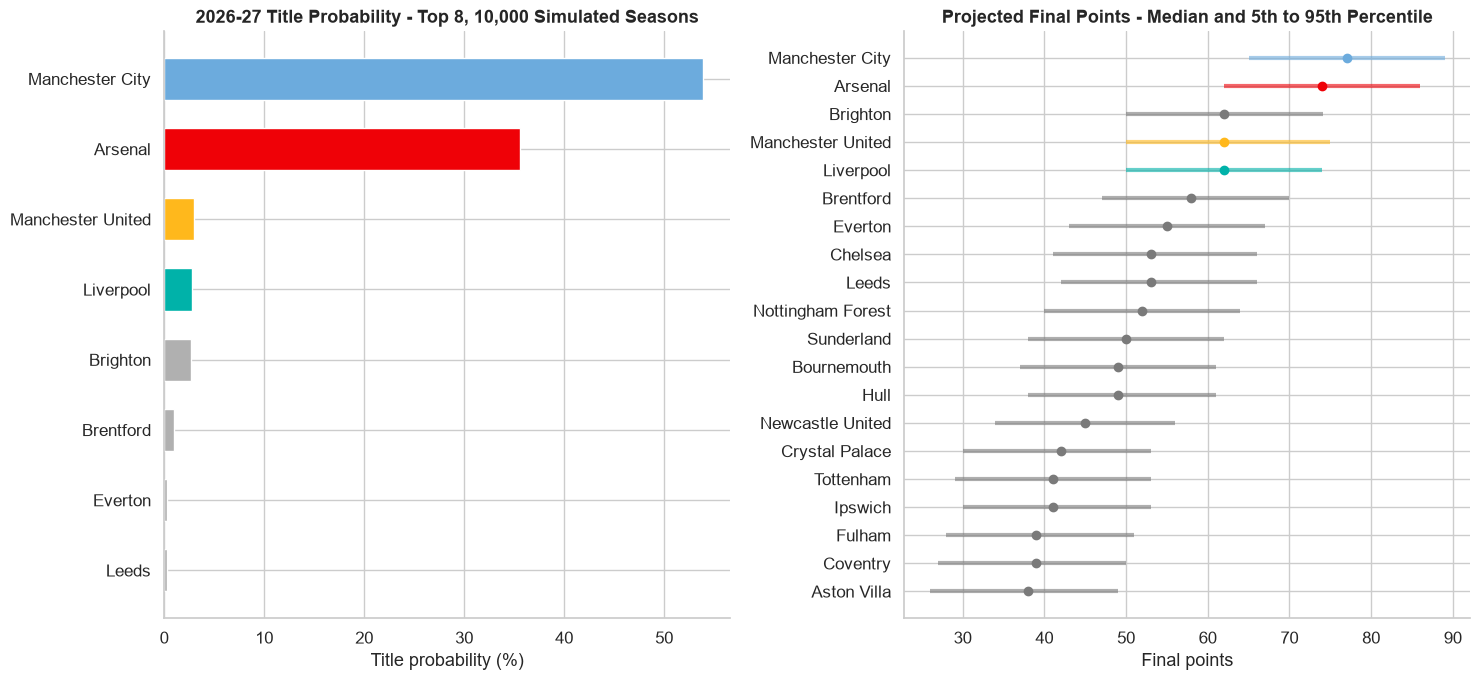

In [22]:
def summarize(final_pts, teams, seed_tiebreak=123):
    tie_rng = np.random.default_rng(seed_tiebreak)
    jitter = tie_rng.random(final_pts.shape) * 1e-6
    order = np.argsort(-(final_pts + jitter), axis=1)
    rank = np.argsort(order, axis=1)
    p5, p50, p95 = np.percentile(final_pts, [5, 50, 95], axis=0)
    return pd.DataFrame({'title_prob': (rank == 0).mean(axis=0), 'top4_prob': (rank <= 3).mean(axis=0),
                         'releg_prob': (rank >= 17).mean(axis=0),
                         'pts_p5': p5, 'pts_median': p50, 'pts_p95': p95},
                        index=teams).sort_values('title_prob', ascending=False)

summary_10k = summarize(final_points, TEAMS20)
print(summary_10k.round(3).to_string())

fig, axes = plt.subplots(1, 2, figsize=(15, 7))

top8 = summary_10k.head(8).sort_values('title_prob')
axes[0].barh(top8.index, top8['title_prob'] * 100,
             color=[TEAM_PALETTE.get(t, '#B0B0B0') for t in top8.index], height=0.6)
axes[0].set_xlabel('Title probability (%)')
axes[0].set_title('2026-27 Title Probability - Top 8, 10,000 Simulated Seasons', fontsize=13, fontweight='bold')

by_median = summary_10k.sort_values('pts_median')
for i, (team, r) in enumerate(by_median.iterrows()):
    colour = TEAM_PALETTE.get(team, '#7A7A7A')
    axes[1].hlines(i, r['pts_p5'], r['pts_p95'], color=colour, linewidth=3, alpha=0.6)
    axes[1].plot(r['pts_median'], i, 'o', color=colour, markersize=6)
axes[1].set_yticks(range(len(by_median)))
axes[1].set_yticklabels(by_median.index)
axes[1].set_xlabel('Final points')
axes[1].set_title('Projected Final Points - Median and 5th to 95th Percentile', fontsize=13, fontweight='bold')

for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

Whether 10,000 runs is enough should be checked instead of assumed: the same simulation at 1,000, 10,000 and 50,000 runs, title probability for the leading clubs.

In [23]:
convergence = {}
for n in [1000, 10000, 50000]:
    fp = run_simulation(fixtures, current_pts, m_final, sc_final, n_runs=n, seed=1)
    convergence[n] = summarize(fp, TEAMS20)['title_prob']
conv_df = pd.DataFrame(convergence)
conv_df.columns = [f'n={c}' for c in conv_df.columns]
print(conv_df.sort_values(conv_df.columns[-1], ascending=False).head(6).round(4))

                   n=1000  n=10000  n=50000
Manchester City     0.537   0.5429   0.5470
Arsenal             0.360   0.3568   0.3529
Manchester United   0.033   0.0282   0.0275
Liverpool           0.024   0.0266   0.0264
Brighton            0.023   0.0256   0.0264
Brentford           0.011   0.0096   0.0089

### Reading Section I

After five gameweeks Manchester City lead with 15 points and Arsenal are on 12. The simulation gives City a 53.9% title probability and Arsenal 35.6%, with projected median finishes of 77 and 74 points, and no other club has more than about 3%. Both are almost certain to finish in the top four (96.3% and 93.2%), while the remaining places are open: Manchester United 46.0%, Liverpool 43.1% and Brighton 42.9%. Relegation is spread across many clubs, led by Aston Villa (56.2%), Coventry (48.5%), Fulham (45.6%), Tottenham (36.4%), Ipswich (33.4%) and Crystal Palace (33.3%).

Convergence is fine. City's title probability is 0.537, 0.543 and 0.547 at 1,000, 10,000 and 50,000 runs, and Arsenal's is 0.360, 0.357 and 0.353, so by 10,000 runs both are within half a point of their 50,000-run values and the order never changes.

The relegation numbers deserve a caution. Aston Villa finished fourth last season on 65 points (Section J) and are now the most likely club to go down, because their snapshot is five matches and nothing carries over from last year. Read these odds as a picture of the current table plus five games of form, not as a judgement of squad quality.

---
## Section J - Does the Simulator Actually Work?

Freeze at a past gameweek of a real, completed season and simulate forward, checking whether the actual final table falls inside the simulated distribution.

In [24]:
BT_SEASON, BT_GW = '2526', 20
season_bt = combined[combined['season'] == BT_SEASON].copy()
TEAMS_BT = sorted(season_bt['team'].unique())
T_IDX_BT = {t: i for i, t in enumerate(TEAMS_BT)}

real_final = season_bt[season_bt['gameweek'] == 38].set_index('team')['cum_pts'].reindex(TEAMS_BT)
as_of = season_bt[season_bt['gameweek'] == BT_GW].set_index('team')['cum_pts'].reindex(TEAMS_BT)
current_pts_bt = as_of.values.astype(float)

print(f'Real champion: {real_final.idxmax()} ({real_final.max():.0f} points)')
print(f'Standings at GW{BT_GW}, top 4:')
print(as_of.sort_values(ascending=False).head(4))

Real champion: Arsenal (85 points)

Standings at GW20, top 4:

team
Arsenal            48.0
Aston Villa        42.0
Manchester City    42.0
Liverpool          34.0
Name: cum_pts, dtype: float64

Same recipe as the live run with two differences. The model is trained only on seasons before 2025-26, and every input (form snapshot, recent form, head-to-head record) is cut off at gameweek 20, so nothing from the rest of that season can reach the simulation.

In [25]:
# form snapshot: the rolling features on each team's GW21 row only use matches up to GW20
snap_bt = season_bt[season_bt['gameweek'] == BT_GW + 1].set_index('team')[SNAP_COLS]
form_bt = last3_form(season_bt[season_bt['gameweek'] <= BT_GW])

# head-to-head history with every result after the cutoff hidden, so nothing from the rest of the season leaks in
cut_date = season_bt.loc[season_bt['gameweek'] == BT_GW, 'date'].max()
h = combined[combined['season'] <= BT_SEASON][['team','opponent','date','points']].sort_values(['team','opponent','date']).copy()
h.loc[h['date'] > cut_date, 'points'] = np.nan
h['h2h_pts_avg3'] = h.groupby(['team','opponent'])['points'].transform(lambda x: x.shift(1).rolling(3, min_periods=1).mean())

remaining_bt = season_bt[season_bt['gameweek'] > BT_GW].drop(columns='h2h_pts_avg3').merge(
    h[['team','opponent','date','h2h_pts_avg3']], on=['team','opponent','date'], how='left')
remaining_bt['h2h_pts_avg3'] = remaining_bt['h2h_pts_avg3'].fillna(1.5)
fixtures_bt = build_fixtures(remaining_bt, snap_bt, form_bt, T_IDX_BT)

# same recipe as the production model, trained only on seasons before the backtest season
bt_train = combined[combined['season'].isin(ARTETA_SEASONS) & (combined['season'] != BT_SEASON)].dropna(subset=FEATURES_FINAL).copy()
bt_train['y'] = bt_train['result'].map(y_map)
sc_bt = StandardScaler()
m_bt = LogisticRegression(max_iter=2000).fit(sc_bt.fit_transform(bt_train[FEATURES_FINAL]), bt_train['y'],
                                             sample_weight=bt_train['recency_weight'])
print(f'Backtest ready: {len(fixtures_bt)} matches to simulate, GW{BT_GW+1}-38 of 2025-26, model trained on {len(bt_train)} rows')

Backtest ready: 180 matches to simulate, GW21-38 of 2025-26, model trained on 4194 rows

In [26]:
fp_bt = run_simulation(fixtures_bt, current_pts_bt, m_bt, sc_bt, n_runs=10000, seed=7)
summ_bt = summarize(fp_bt, TEAMS_BT)
print(summ_bt.round(4).head(6).to_string())

                   title_prob  top4_prob  releg_prob  pts_p5  pts_median  pts_p95
Arsenal                0.8566     0.9997      0.0000    76.0        85.0     93.0
Manchester City        0.1290     0.9848      0.0000    67.0        76.0     85.0
Liverpool              0.0089     0.7767      0.0000    59.0        68.0     77.0
Aston Villa            0.0052     0.7353      0.0000    58.0        67.0     76.0
Manchester United      0.0002     0.1678      0.0000    50.0        59.0     69.0
Newcastle United       0.0001     0.0930      0.0002    48.0        57.0     66.0

The comparison between each club's real final points and the simulated 5th to 95th percentile range. Grey bars are the simulated range, the tick is the simulated median and the dot is the real result, green if it landed inside the range and red if it did not.

                   real_final_pts  sim_p5  sim_median  sim_p95  inside_band
team                                                                       
Arsenal                      85.0    76.0        85.0     93.0         True
Manchester City              78.0    67.0        76.0     85.0         True
Manchester United            71.0    50.0        59.0     69.0        False
Aston Villa                  65.0    58.0        67.0     76.0         True
Liverpool                    60.0    59.0        68.0     77.0         True
Bournemouth                  57.0    39.0        47.0     56.0        False
Sunderland                   54.0    43.0        51.0     60.0         True
Brentford                    53.0    47.0        56.0     65.0         True
Brighton                     53.0    41.0        50.0     59.0         True
Fulham                       52.0    43.0        51.0     60.0         True

Real champion (Arsenal) simulated title probability: 0.8566

Teams with real final points inside their simulated 5-95 band: 17 / 20

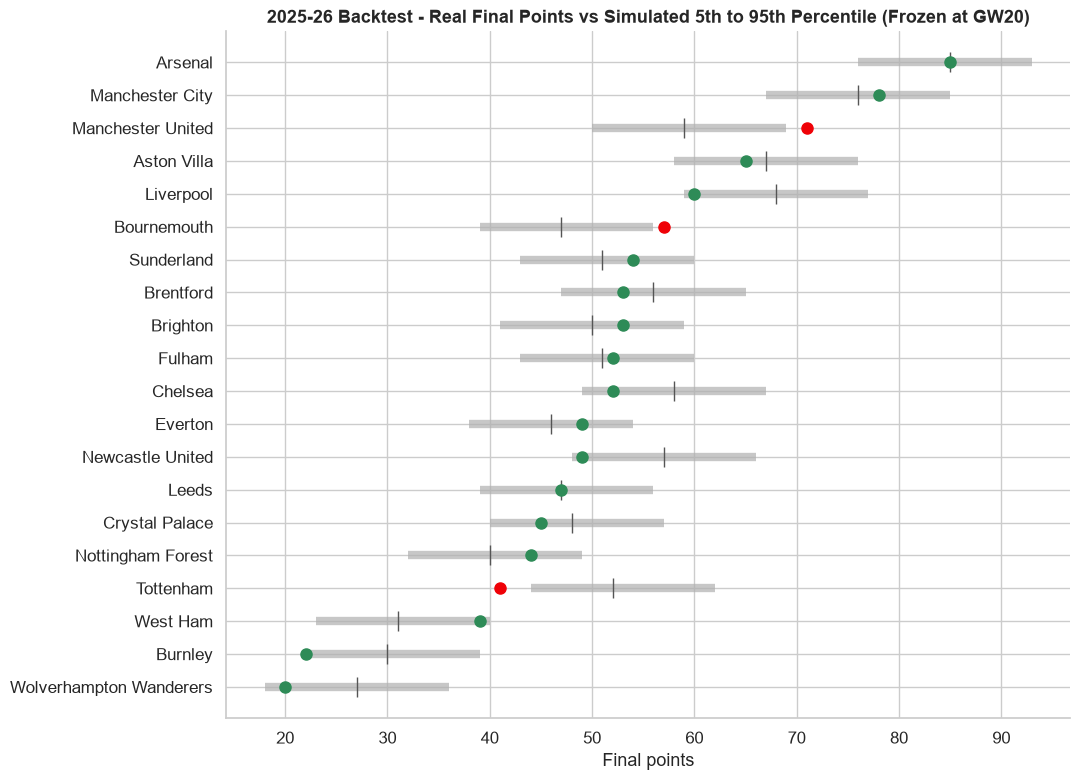

In [27]:
comparison = pd.DataFrame({
    'real_final_pts': real_final, 'sim_p5': summ_bt['pts_p5'], 'sim_median': summ_bt['pts_median'], 'sim_p95': summ_bt['pts_p95'],
}).reindex(real_final.sort_values(ascending=False).index)
comparison['inside_band'] = (comparison['real_final_pts'] >= comparison['sim_p5']) & (comparison['real_final_pts'] <= comparison['sim_p95'])

print(comparison.head(10).round(1))
print()
print(f'Real champion ({real_final.idxmax()}) simulated title probability: {summ_bt.loc[real_final.idxmax(), "title_prob"]:.4f}')
print(f'Teams with real final points inside their simulated 5-95 band: {comparison["inside_band"].sum()} / 20')

fig, ax = plt.subplots(figsize=(11, 8))
plot_df = comparison.iloc[::-1]
for i, (team, r) in enumerate(plot_df.iterrows()):
    ax.hlines(i, r['sim_p5'], r['sim_p95'], color='#B0B0B0', linewidth=6, alpha=0.7)
    ax.plot(r['sim_median'], i, '|', color='#555555', markersize=14)
    ax.plot(r['real_final_pts'], i, 'o', markersize=8, color=('#2E8B57' if r['inside_band'] else TEAM_PALETTE['Arsenal']))
ax.set_yticks(range(len(plot_df)))
ax.set_yticklabels(plot_df.index)
ax.set_xlabel('Final points')
ax.set_title('2025-26 Backtest - Real Final Points vs Simulated 5th to 95th Percentile (Frozen at GW20)', fontsize=13, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

### Reading Section J

Frozen at gameweek 20, with Arsenal on 48 points against 42 for Aston Villa and Manchester City, the simulation gives Arsenal, the real champion, an 85.7% title probability, and its median (85 points) equals what they finished on. Seventeen of the 20 clubs finished inside their 5th to 95th percentile range. The three that did not are Manchester United (71 points against a range of 50 to 69), Bournemouth (57 against 39 to 56) and Tottenham (41 against 44 to 62), two clubs that beat their form and one that fell short of it. A range meant to cover 90% should miss about two clubs in twenty, so 17 of 20 is a little under nominal but close.

The same backtest frozen at gameweek 5 instead, by setting BT_GW to 5 and rerunning the cells below it, is much weaker. Arsenal's title probability falls to 29.7% and only 14 of 20 clubs land inside their range, with Aston Villa (65 real points, simulated range 28 to 51) the biggest miss. That is the position the live run is in now. The method works when it has a season's worth of form to freeze, and it is a rougher tool this early, so the live odds are best read with that in mind.

---
## Key Findings Summary

In [28]:
arsenal_releg = snap_35.set_index('team').loc['Arsenal', 'releg_gap']
top2 = summary_10k.head(2)
top_releg = summary_10k.sort_values('releg_prob', ascending=False).head(3)
champ = real_final.idxmax()

print('=' * 70)
print('KEY FINDINGS - 2026-27 Live Title Simulation')
print('=' * 70)
print()
print('1. THE LIVE DATA HAD TO COME FROM A LIVE SOURCE')
print(f"   NB01's FBRef fixture file showed {fx_old['scored'].notna().sum()} played rows and no xG. Understat, pulled with")
print(f"   no_cache=True, had {live_2627['scored'].notna().sum() // 2} real results with xG through gameweek {live_2627.loc[live_2627['scored'].notna(), 'gameweek'].max()}, and its")
print('   team names already match the historical ones apart from the two promoted clubs.')
print()
print('2. TWO SEPARATE MODELS WOULD HAVE BUILT IN A BIAS')
print(f'   For a perfectly average match the four-team model gives a {p_avg_t1[2]:.1%} win probability and')
print(f'   the all-20 model gives {p_avg_t2[2]:.1%}, a gap of {(p_avg_t1[2] - p_avg_t2[2]) * 100:.1f} points before any feature is used.')
print('   One model fitted on all 20 teams gives every club the same starting point.')
print()
print('3. STAKES_INTENSITY NEEDED A RELEGATION BOUNDARY AND A WIDER SCOPE')
print('   None of the four tracked teams has faced relegation, so NB02 never needed a relegation')
print('   boundary. Reusing boundary_gap gave every safe club the same releg_gap, Arsenal on 76 points')
print(f'   included. Measuring each club against its own distance above 18th fixes it (Arsenal is now')
print(f'   {arsenal_releg:.0f}). stakes_intensity is now computed for all 20 clubs instead of being zero for sixteen.')
print()
print('4. ONE NEW FEATURE EARNED ITS PLACE')
print(f'   Head-to-head record moved validation log loss from {ll_without:.4f} to {ll_with:.4f} against a dummy')
print(f'   baseline of {ll_dummy:.4f}. Separate attack and defence opponent terms, an is_promoted flag and a')
print('   stakes-times-Big-6 interaction were tested the same way and did not help.')
print()
print('5. FORM IS FROZEN, STAKES IS NOT')
print('   Rolling form is fixed at its current value for the rest of the season, in line with NB06, where')
print('   retraining through the season did not help. stakes_intensity is recomputed at every simulated')
print('   gameweek from the simulated table, because it describes table position, not form.')
print()
print('6. THE LIVE RESULT')
print(f"   {top2.index[0]} {top2['title_prob'].iloc[0]:.1%} and {top2.index[1]} {top2['title_prob'].iloc[1]:.1%} for the title, with projected median finishes of")
print(f"   {top2['pts_median'].iloc[0]:.0f} and {top2['pts_median'].iloc[1]:.0f} points. Highest relegation risk: " + ', '.join(f'{t} {p:.1%}' for t, p in zip(top_releg.index, top_releg['releg_prob'])) + '.')
print()
print('7. THE SIMULATOR VALIDATES AGAINST A COMPLETED SEASON, WITH A CAVEAT')
print(f"   Frozen at gameweek 20 of 2025-26, the real champion ({champ}) got a title probability of {summ_bt.loc[champ, 'title_prob']:.1%} and")
print(f"   {comparison['inside_band'].sum()} of 20 clubs finished inside their simulated range. Frozen at gameweek 5 the same")
print('   test is much weaker (Arsenal 29.7%, 14 of 20), so early-season odds are the least reliable.')
print()
print('LIMITATIONS')
print('   Ties are broken at random because the model predicts win, draw or loss and never a scoreline.')
print('   Rolling form restarts every season, so early in the year a snapshot rests on a handful of matches.')
print("   stakes_intensity in the historical rows is built from standings that include the match itself (an")
print('   NB02 choice), while the simulation uses the standings before it. Recomputing it from the pre-match')
print('   table in a separate check moved validation log loss by about 0.001, so it was left as it is.')

KEY FINDINGS - 2026-27 Live Title Simulation

1. THE LIVE DATA HAD TO COME FROM A LIVE SOURCE

   NB01's FBRef fixture file showed 20 played rows and no xG. Understat, pulled with

   no_cache=True, had 50 real results with xG through gameweek 5, and its

   team names already match the historical ones apart from the two promoted clubs.

...

   Ties are broken at random because the model predicts win, draw or loss and never a scoreline.

   Rolling form restarts every season, so early in the year a snapshot rests on a handful of matches.

   stakes_intensity in the historical rows is built from standings that include the match itself (an

   NB02 choice), while the simulation uses the standings before it. Recomputing it from the pre-match

   table in a separate check moved validation log loss by about 0.001, so it was left as it is.